## Librerias

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Carga datos clean

In [3]:
df_operaciones = pd.read_csv('../../data/data_cleaning/operaciones_11-03-2026.csv', parse_dates=['insert_date'])

availability_cols = [
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365"
]

FileNotFoundError: [Errno 2] No such file or directory: '../../data/data_cleaning/operaciones_11-03-2026.csv'

## Análisis / visualizaciones
Quina és la disponibilitat mitjana dels allotjaments
turístics en els diferents terminis (30, 60, 90 i 365 dies) a cada ciutat?

In [ ]:
disponibilidad_ciudad_raw = (
    df_operaciones
    .groupby("city")[availability_cols]
    .mean()
    .round(1)
    .reset_index()
)

disponibilidad_ciudad_raw

NameError: name 'df_operaciones' is not defined

In [ ]:
df_operaciones["avail_ratio_30"] = df_operaciones["availability_30"] / 30
df_operaciones["avail_ratio_60"] = df_operaciones["availability_60"] / 60
df_operaciones["avail_ratio_90"] = df_operaciones["availability_90"] / 90
df_operaciones["avail_ratio_365"] = df_operaciones["availability_365"] / 365

avail_ratio_cols = [
    "avail_ratio_30",
    "avail_ratio_60",
    "avail_ratio_90",
    "avail_ratio_365"
]

disponibilidad_ciudad = (
    df_operaciones
    .groupby("city")[avail_ratio_cols]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
)

disponibilidad_ciudad

,city,avail_ratio_30,avail_ratio_60,avail_ratio_90,avail_ratio_365
0,Barcelona,36.8,42.5,47.0,49.7
1,Girona,48.0,51.7,53.4,53.2
2,Madrid,34.6,40.2,44.4,44.8
3,Malaga,40.6,47.7,52.7,55.6
4,Mallorca,43.5,46.9,49.4,57.1
5,Menorca,48.8,50.4,52.4,54.1
6,Sevilla,45.9,50.5,55.0,54.5
7,Valencia,44.8,49.1,52.7,50.2


In [ ]:
df_ciudad = (
    df_operaciones
    .groupby("city")
    .agg(
        oferta=("apartment_id", "nunique"),
        disponibilidad_media=("avail_ratio_30", "mean")
    )
    .reset_index()
)

df_ciudad["disponibilidad_media"] = (df_ciudad["disponibilidad_media"] * 100).round(1)
df_ciudad

,city,oferta,disponibilidad_media
0,Barcelona,2016,36.8
1,Girona,1071,48.0
2,Madrid,1386,34.6
3,Malaga,339,40.6
4,Mallorca,1036,43.5
5,Menorca,134,48.8
6,Sevilla,339,45.9
7,Valencia,294,44.8


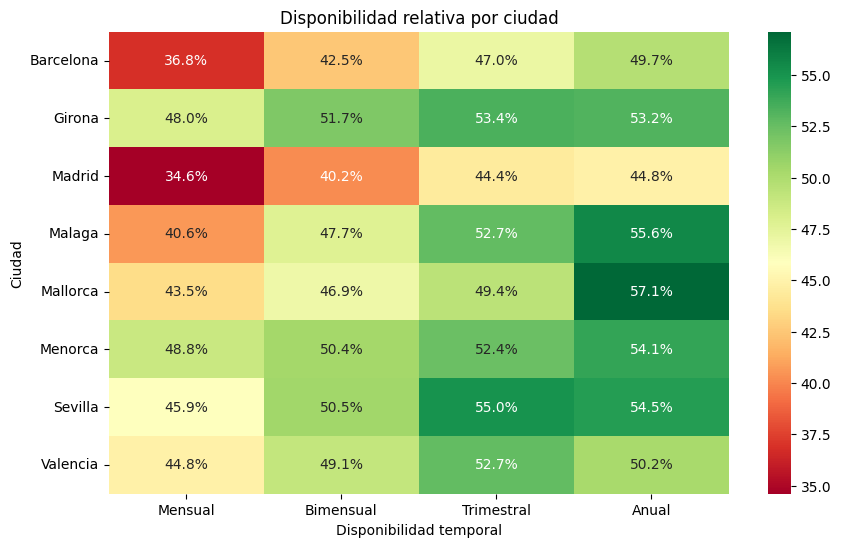

In [ ]:
data = disponibilidad_ciudad.set_index("city")
labels = data.round(2).astype(str) + "%"

fig, ax = plt.subplots(figsize=(10,6))

sns.heatmap(
    data,
    annot=labels,
    cmap="RdYlGn",
    fmt=""
)

ax.set_title("Disponibilidad relativa por ciudad")
ax.set_ylabel("Ciudad")
ax.set_xlabel("Disponibilidad temporal")
ax.set_xticklabels(["Mensual","Bimensual","Trimestral","Anual"])

plt.show()

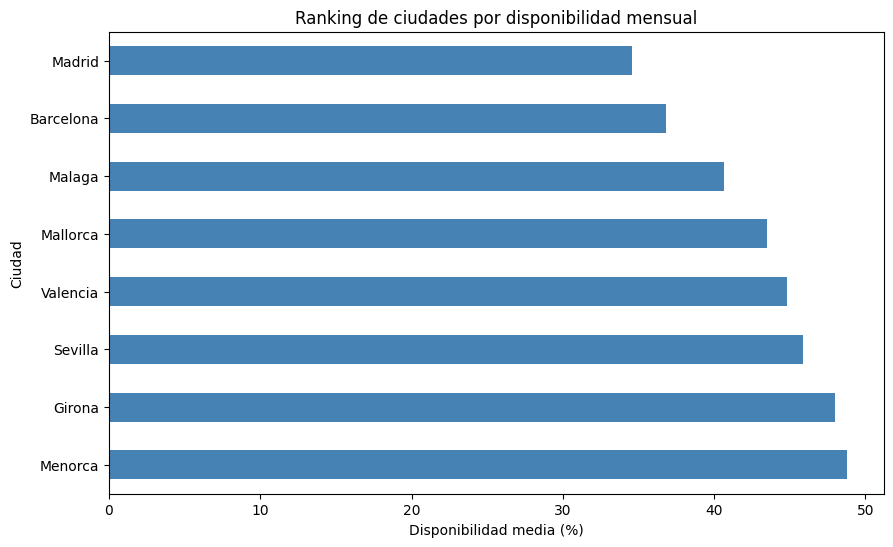

In [ ]:
disponibilidad_mensual = (
    df_operaciones
    .groupby("city")["avail_ratio_30"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10,6))

disponibilidad_mensual.plot(
    kind="barh",
    color="steelblue"
)

ax.set_xlabel("Disponibilidad media (%)")
ax.set_ylabel("Ciudad")
ax.set_title("Ranking de ciudades por disponibilidad mensual")

plt.show()

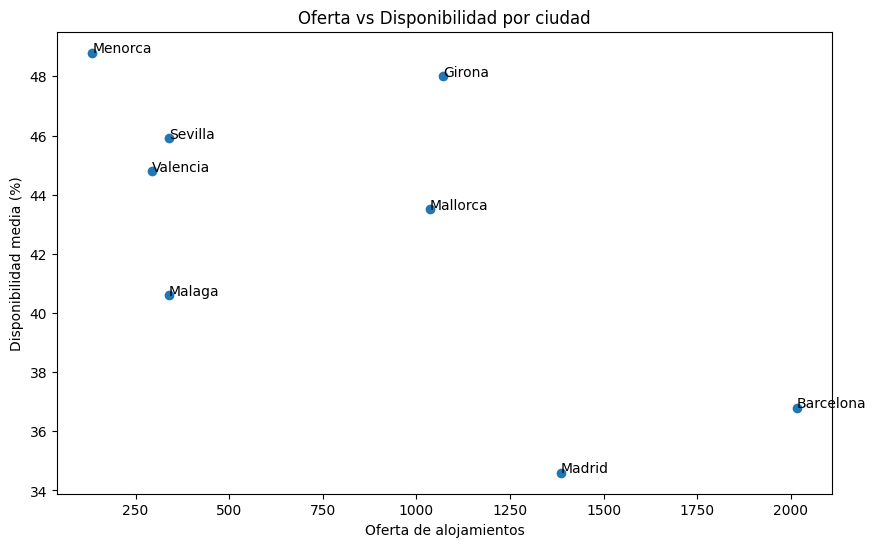

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(
    df_ciudad["oferta"],
    df_ciudad["disponibilidad_media"]
)

for i, row in df_ciudad.iterrows():
    ax.text(
        row["oferta"],
        row["disponibilidad_media"],
        row["city"]
    )

ax.set_xlabel("Oferta de alojamientos")
ax.set_ylabel("Disponibilidad media (%)")
ax.set_title("Oferta vs Disponibilidad por ciudad")

plt.show()

## Resultados / archivos generados